<a href="https://colab.research.google.com/github/sasirajesh/FedXGB-OptDP/blob/main/housing_price_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install deap

# 🏠 Federated XGBoost (DAD-NAR) for Housing Price Dataset (Regression)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Price Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"
df = pd.read_csv(file_path)

# Try to detect target column automatically
possible_targets = ['price', 'Price', 'house_price', 'median_value', 'target', 'SalePrice']
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break
if target_col is None:
    raise ValueError("Couldn't detect target column automatically! Please specify manually.")

y = df[target_col].values
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Dataset shape:", df.shape)
print("Target variable:", target_col)
print("Feature count:", X.shape[1])

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split (KFold)
# ==========================================
num_clients = 3
client_data, client_labels = [], []

kf = KFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in kf.split(X):
    X_i, y_i = X[idxs], y[idxs]
    client_data.append(X_i)
    client_labels.append(y_i)

print("\n✅ Federated client data created successfully.")

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

# ==========================================
# 5️⃣ Helper Functions (DP + DAD + NAR)
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 6️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X, y, n_gen=10, n_pop=10, k_features=10):
    n_features = X.shape[1]
    if "FitnessMin" not in creator.__dict__:
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 999999.,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
        model = XGBRegressor(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        return mse,

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best)[-k_features:]
    return top_k_idx

# ==========================================
# 7️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBRegressor(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mse = mean_squared_error(y_val, preds)
        return mse

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 8️⃣ Local Client Training
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10)
    X_sel = X[:, top_features]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
    model = XGBRegressor(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        random_state=SEED
    )
    model.fit(X_train, y_train)

    # DAD-NAR privacy simulation
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    return {'model': model, 'top_features': top_features, 'hyperparams': best_params,
            'mse': mse, 'r2': r2, 'mae': mae}

# ==========================================
# 9️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → MSE: {res['mse']:.4f}, R2: {res['r2']:.4f}, MAE: {res['mae']:.4f}")

# ==========================================
# 🔟 Server Aggregation (No Retraining)
# ==========================================
avg_mse = np.mean([r['mse'] for r in clients_results])
avg_r2 = np.mean([r['r2'] for r in clients_results])
avg_mae = np.mean([r['mae'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results])
(consensus_features, counts) = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average MSE: {avg_mse:.4f}")
print(f"Average R²: {avg_r2:.4f}")
print(f"Average MAE: {avg_mae:.4f}")
print(f"Consensus Top Features: {top_features_final}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.3 MB/s eta 0:00:00
Dataset shape: (545, 13)
Target variable: price
Feature count: 5

✅ Federated client data created successfully.

🔹 Training Client 1
100%|██████████| 10/10 [00:00<00:00, 19.02trial/s, best loss: 1970966495232.0]
Client 1 → MSE: 1970966495232.0000, R2: 0.3910, MAE: 1085145.1250

🔹 Training Client 2
100%|██████████| 10/10 [00:00<00:00, 28.43trial/s, best loss: 1264840081408.0]
Client 2 → MSE: 1402104315904.0000, R2: 0.3142, MAE: 934775.9375

🔹 Training Client 3
100%|██████████| 10/10 [00:00<00:00, 21.03trial/s, best loss: 1483029610496.0]
Client 3 → MSE: 1490840322048.0000, R2: 0.5054, MAE: 955486.7500

✅ Final Aggregation Results:
Average MSE: 1621303711061.3333
Average R²: 0.4035
Average MAE: 991802.6042
Consensus Top Features: [0 1 2 3 4]


In [ ]:
# 🏠 Federated XGBoost (OptDP) for Housing Price Dataset (Binary Classification)
# ============================================================
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load Housing Price Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"   # Update this path as needed
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Detect target column (price)
if 'price' not in df.columns:
    raise ValueError("Target column 'price' not found in dataset!")

X = df.drop(columns=['price'])
y_reg = df['price']

# Convert regression → binary classification (High vs Low price)
median_price = y_reg.median()
y = (y_reg > median_price).astype(int)

print("\nMedian price used for binary conversion:", median_price)
print("Label distribution:\n", pd.Series(y).value_counts())

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 2️⃣ Federated Client Split (Stratified)
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in skf.split(X, y):
    X_i, y_i = X[idxs], y[idxs]
    client_data.append(X_i)
    client_labels.append(y_i)

print("\n✅ Federated clients created successfully!")
for i in range(num_clients):
    print(f"Client {i+1} label distribution:\n", pd.Series(client_labels[i]).value_counts())

# ==========================================
# 3️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=10):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(
            X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        model = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=50, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        return acc,

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_ind = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best_ind) if bit == 1]
    if len(selected_features) == 0:
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

# ==========================================
# 4️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_local, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.1, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 5️⃣ Local Client Training
# ==========================================
def train_client_model(X_local, y_local):
    best_params = optimize_hyperparams(X_local, y_local)
    top_features = ga_feature_selection(X_local, y_local, n_gen=5, n_pop=8, k_features=10)
    X_sel = X_local[:, top_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'top_features': top_features, 'acc': acc, 'f1': f1}

# ==========================================
# 6️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Accuracy: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 7️⃣ Server Aggregation (No Retraining)
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results])
(consensus_features, counts) = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_features_final}")


Dataset shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Median price used for binary conversion: 4340000.0
Label distribution:
 price
0    275
1    270
Name: count, dtype: int64

✅ Federated clients created successfully!
Client 1 label distribution:
 price
0    92
1    90
Name: count, dtype: int64
Client 2 label distribution:
 price
0    92
1    90
Name: count, dtype: int64
Client 3 label distribution:
 price
0    91
1    90
Name: count, dtype: int64

🔹 Training Client 1
100%|██████████| 10/10 [00:00<00:00, 28.94trial/s, best loss: -0.8181818181818182]
Client 1 → Accuracy: 0.5091, F1: 0.0690

🔹 Training Client 2
100%|██████████| 10/10 [00:00<00:00, 22.18trial/s, best loss: -0.8181818181818182]
Client 2 → Accuracy: 0.5455, F1: 0.5283

🔹 Training Client 3
100%|██████████| 10/10 [00:00<00:00, 25.90trial/s, best loss: -0.8]
Client 3 → Accura

In [ ]:
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=12, k_features=8):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)
        clf = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best) if bit == 1]
    if len(selected_features) == 0:
        # Fallback: select features with highest variance if GA selects no features
        # This ensures X_sel is never empty
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

In [ ]:
# ============================================================
# 🏠 Federated XGBoost (Work 2: FedXGB-OptDP) – Housing Price Dataset
# ============================================================
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"   # ✅ change path if needed
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "price"
if target_col not in df.columns:
    raise ValueError("Expected column 'price' not found!")

# ✅ Convert price to binary classification (above median = 1)
median_price = df[target_col].median()
y = (df[target_col] > median_price).astype(int)
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Target distribution:\n", pd.Series(y).value_counts())

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []
skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)

for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

print(f"\n✅ Federated client data created successfully ({num_clients} clients)")

# ==========================================
# 4️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=12, k_features=8):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)
        clf = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best) if bit == 1]
    if len(selected_features) == 0:
        # Fallback: select features with highest variance if GA selects no features
        # This ensures X_sel is never empty
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

# ==========================================
# 5️⃣ Hyperparameter Optimization (Fine-tuned)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            gamma=params['gamma'],
            reg_lambda=params['reg_lambda'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return -acc

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
        'max_depth': hp.quniform('max_depth', 3, 8, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
        'min_child_weight': hp.uniform('min_child_weight', 1, 6),
        'gamma': hp.uniform('gamma', 0, 0.5),
        'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=40, trials=trials)
    return best

# ==========================================
# 6️⃣ Local Client Training
# ==========================================
def train_client_model(X_local, y_local):
    print(" → Optimizing hyperparameters...")
    best_params = optimize_hyperparams(X_local, y_local)
    print(" → Performing GA feature selection...")
    top_features = ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=8)
    X_sel = X_local[:, top_features]
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=best_params['min_child_weight'],
        gamma=best_params['gamma'],
        reg_lambda=best_params['reg_lambda'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'acc': acc, 'f1': f1, 'features': top_features, 'params': best_params}

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Accuracy: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])
all_feats = np.concatenate([r['features'] for r in clients_results])
(consensus, counts) = np.unique(all_feats, return_counts=True)
top_feats_final = consensus[np.argsort(-counts)[:8]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_feats_final}")


Dataset shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target distribution:
 price
0    275
1    270
Name: count, dtype: int64

✅ Federated client data created successfully (3 clients)

🔹 Training Client 1
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:01<00:00, 21.84trial/s, best loss: -0.8545454545454545]
 → Performing GA feature selection...
Client 1 → Accuracy: 0.8909, F1: 0.8929

🔹 Training Client 2
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:03<00:00, 11.83trial/s, best loss: -0.8727272727272727]
 → Performing GA feature selection...
Client 2 → Accuracy: 0.7091, F1: 0.7241

🔹 Training Client 3
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:01<00:00, 22.45trial/s, best loss: -0.8545454545454545]
 → Performing GA feature selection...
Client 3 → Accuracy: 0.5455, F1: 0.6377

✅ Final Aggregatio

Dataset columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Numeric features shape: (545, 5)
Train shape: (408, 5), Test shape: (137, 5), Classes: [0 1]


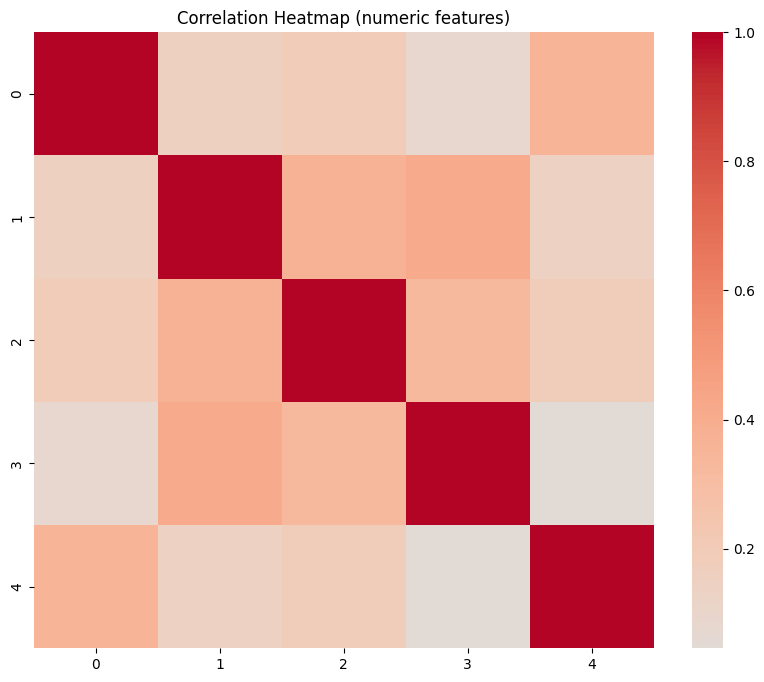


=== Experiment A: Centralized (No DP) ===
Selected features (A): [3 0 1 2 4]
100%|██████████| 20/20 [00:00<00:00, 20.44trial/s, best loss: -0.7642276422764228]
Hyperparams (A): {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.06848287379079836, 'subsample': 0.9124351334655565, 'colsample_bytree': 0.702289615330813}
A - Acc: 0.7956, F1: 0.7971, LogLoss: 0.4437


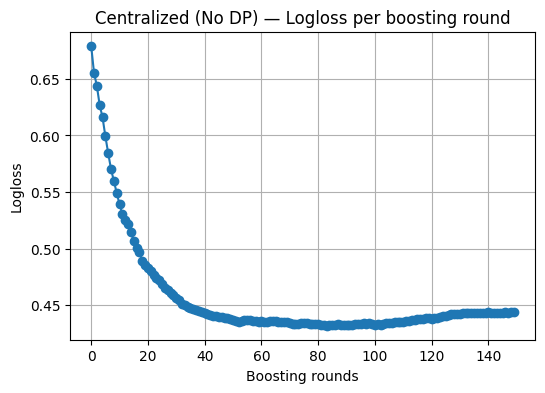

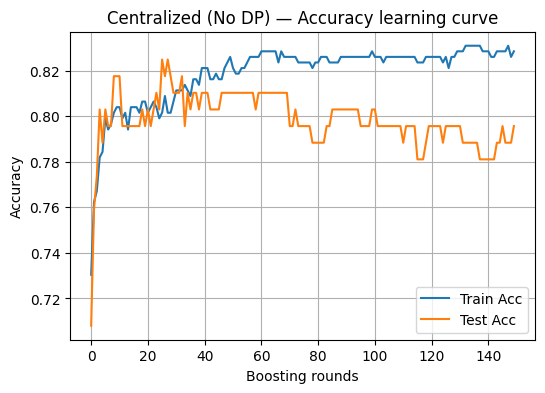


=== Experiment B: Centralized + DAD-NAR (Output Perturbation DP) ===
Epsilons by depth: [0.01     0.006703 0.004493 0.003012 0.002019]
Effective epsilon (sum over depths): 0.026227397400597183
epsilon=0.006557 → Acc=0.4672, F1=0.4511
epsilon=0.013114 → Acc=0.4526, F1=0.4828
epsilon=0.026227 → Acc=0.4818, F1=0.4818
epsilon=0.052455 → Acc=0.4672, F1=0.5034
epsilon=0.131137 → Acc=0.5036, F1=0.4603


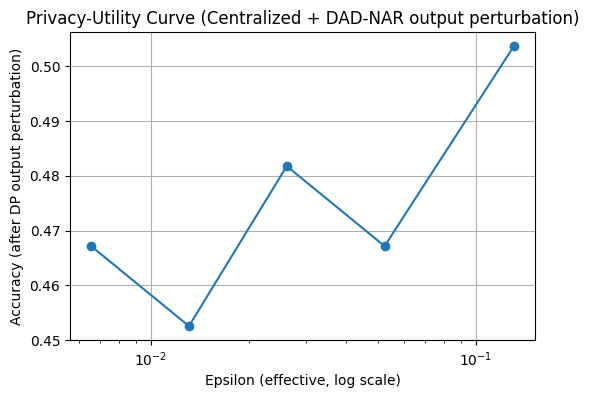


=== Experiment C: Federated (No DP) ===

--- Local client 1: running GA+Hyperopt (light) ---
100%|██████████| 12/12 [00:00<00:00, 32.98trial/s, best loss: -0.6585365853658537]
client 1 feats: [2 4 1 0 3], params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.17517762409420815, 'subsample': 0.8796314378966033, 'colsample_bytree': 0.8024843254943301}

--- Local client 2: running GA+Hyperopt (light) ---
100%|██████████| 12/12 [00:00<00:00, 30.80trial/s, best loss: -0.926829268292683]
client 2 feats: [3 0 1 2 4], params: {'n_estimators': 90, 'max_depth': 5, 'learning_rate': 0.03986414310676045, 'subsample': 0.658785114914011, 'colsample_bytree': 0.8290912476031544}

--- Local client 3: running GA+Hyperopt (light) ---
100%|██████████| 12/12 [00:00<00:00, 33.31trial/s, best loss: -0.6341463414634146]
client 3 feats: [0 2 4 1 3], params: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.0213878759254661, 'subsample': 0.7201685419162034, 'colsample_bytree': 0.82563541224115}

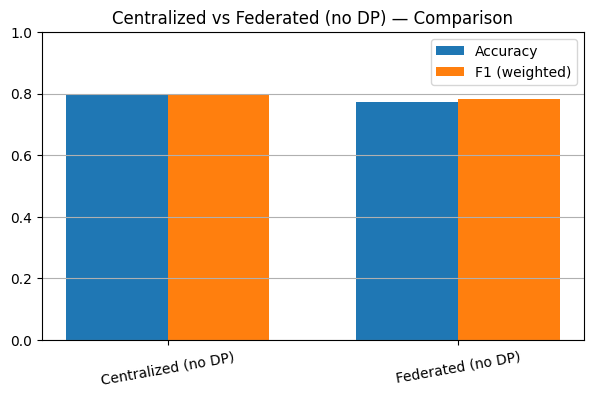

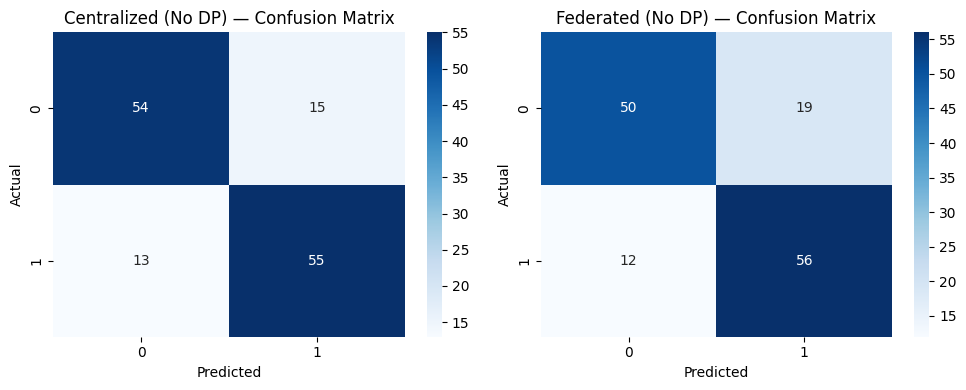


Classification Report (Centralized, No DP):
               precision    recall  f1-score   support

           0       0.81      0.78      0.79        69
           1       0.79      0.81      0.80        68

    accuracy                           0.80       137
   macro avg       0.80      0.80      0.80       137
weighted avg       0.80      0.80      0.80       137


Classification Report (Federated, No DP):
               precision    recall  f1-score   support

           0       0.81      0.72      0.76        69
           1       0.75      0.82      0.78        68

    accuracy                           0.77       137
   macro avg       0.78      0.77      0.77       137
weighted avg       0.78      0.77      0.77       137



In [ ]:
# ============================================================
# All-in-One: Centralized (no DP), Centralized + DAD-NAR (DP),
# and Federated (no DP) — Housing Price (binary) experiments
# ============================================================
import numpy as np
import pandas as pd
import random, math, warnings, os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, classification_report

from xgboost import XGBClassifier, DMatrix, Booster
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.max_open_warning': 0})

# ----------------------------
# CONFIG: adjust paths / budgets
# ----------------------------
FILE_PATH = "/content/Housing_Price_Data.csv"   # <-- adjust if needed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# DAD-NAR parameters (used in DP experiment)
num_trees = 100
max_depth = 5
alpha = 0.4        # depth-decay for epsilon
beta = 0.25        # dropout depth parameter (not used for training here; for simulation)
lambda0 = 1.0
epsilon_local = 1.0   # total local budget (you can change to 0.5, 1, 2 ...)

# ----------------------------
# 1) Load dataset & preprocess
# ----------------------------
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Dataset file not found: {FILE_PATH}")

df = pd.read_csv(FILE_PATH)
print("Dataset columns:", df.columns.tolist())
if 'price' not in df.columns:
    raise ValueError("Expected numeric column named 'price' in the dataset")

# Target -> binary (> median price => 1)
median_price = df['price'].median()
y_all = (df['price'] > median_price).astype(int).values

# Use only numeric features for simplicity (drop price)
X_all = df.drop(columns=['price']).select_dtypes(include=[np.number]).values
print("Numeric features shape:", X_all.shape)

# Standardize features
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

# Train/test split (global) — will be used by centralized experiments
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=SEED
)
print(f"Train shape: {X_train_full.shape}, Test shape: {X_test_full.shape}, Classes: {np.unique(y_all)}")

# Correlation heatmap (optional)
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_all).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.show()


# ----------------------------
# Utility: GA feature selection (works on any X,y)
# ----------------------------
def ga_feature_selection(X, y, n_gen=10, n_pop=12, k_features=8):
    n_features = X.shape[1]
    # create types if not already present
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            # Fallback: select features with highest variance if GA selects no features
            # This ensures X_sel is never empty and prevents XGBoostError
            if n_features == 0:
                return 0.0, # Cannot select features if there are none
            selected_features = list(np.argsort(np.var(X, axis=0))[-k_features:])
            Xs = X[:, selected_features]
        else:
            Xs = X[:, idx]

        Xtr, Xval, ytr, yval = train_test_split(Xs, y, test_size=0.3, stratify=y, random_state=SEED)
        clf = XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.05, eval_metric='logloss', use_label_encoder=False, random_state=SEED)
        clf.fit(Xtr, ytr)
        return accuracy_score(yval, clf.predict(Xval)),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    arr = np.array(best, dtype=int)
    if arr.sum() == 0:
        # fallback: highest variance features
        if n_features == 0:
             return np.array([]) # Return empty if no features to begin with
        vars_ = X.var(axis=0)
        return np.argsort(-vars_)[:k_features]
    topk = np.argsort(-arr)[:k_features]
    return np.array(topk, dtype=int)


# ----------------------------
# Utility: Hyperopt for XGBoost (light)
# ----------------------------
def optimize_hyperparams(X, y, max_evals=20):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=SEED
        )
        Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
        model.fit(Xtr, ytr)
        return -accuracy_score(yval, model.predict(Xval))

    space = {
        'n_estimators': hp.quniform('n_estimators', 80, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
    }
    trials = Trials()
    best = fmin(objective, space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    # convert numeric params
    return {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }


# ----------------------------
# Experiment A: Centralized, No DP
# ----------------------------
print("\n=== Experiment A: Centralized (No DP) ===")
# GA on full training set
top_feats_A = ga_feature_selection(X_train_full, y_train_full, n_gen=12, n_pop=14, k_features=8)
print("Selected features (A):", top_feats_A)

# Hyperopt
hp_A = optimize_hyperparams(X_train_full[:, top_feats_A], y_train_full, max_evals=20)
print("Hyperparams (A):", hp_A)

# Train final centralized model with eval logging
model_A = XGBClassifier(**hp_A, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=SEED)
# Remove evals_result from fit, retrieve after fitting
model_A.fit(X_train_full[:, top_feats_A], y_train_full, eval_set=[(X_test_full[:, top_feats_A], y_test_full)], verbose=False)
evals_result_A = model_A.evals_result()

pred_A = model_A.predict(X_test_full[:, top_feats_A])
prob_A = model_A.predict_proba(X_test_full[:, top_feats_A])[:,1]
acc_A = accuracy_score(y_test_full, pred_A)
f1_A = f1_score(y_test_full, pred_A)
lloss_A = log_loss(y_test_full, prob_A)
print(f"A - Acc: {acc_A:.4f}, F1: {f1_A:.4f}, LogLoss: {lloss_A:.4f}")


# Plot learning curves for A
train_logloss_A = evals_result_A['validation_0']['logloss']
plt.figure(figsize=(6,4))
plt.plot(train_logloss_A, marker='o')
plt.title("Centralized (No DP) — Logloss per boosting round")
plt.xlabel("Boosting rounds")
plt.ylabel("Logloss")
plt.grid(True)
plt.show()

# Accuracy per round (recompute using booster)
booster_A: Booster = model_A.get_booster()
trainD_A = DMatrix(X_train_full[:, top_feats_A], label=y_train_full)
testD_A = DMatrix(X_test_full[:, top_feats_A], label=y_test_full)
train_acc_curve_A, test_acc_curve_A = [], []
n_rounds = len(train_logloss_A)
for r in range(n_rounds):
    p_tr = (booster_A.predict(trainD_A, iteration_range=(0, r+1)) > 0.5).astype(int)
    p_te = (booster_A.predict(testD_A, iteration_range=(0, r+1)) > 0.5).astype(int)
    train_acc_curve_A.append(accuracy_score(y_train_full, p_tr))
    test_acc_curve_A.append(accuracy_score(y_test_full, p_te))

plt.figure(figsize=(6,4))
plt.plot(train_acc_curve_A, label='Train Acc')
plt.plot(test_acc_curve_A, label='Test Acc')
plt.title("Centralized (No DP) — Accuracy learning curve")
plt.xlabel("Boosting rounds")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()


# ----------------------------
# DAD-NAR helper: depth-adaptive epsilons
# ----------------------------
def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * math.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - math.exp(-beta * depth)


# ----------------------------
# Experiment B: Centralized + DAD-NAR (privacy, output perturbation)
# ----------------------------
print("\n=== Experiment B: Centralized + DAD-NAR (Output Perturbation DP) ===")
eps_tree = epsilon_local / num_trees
eps_by_depth = [depth_adaptive_epsilon(eps_tree, d) for d in range(max_depth)]
print("Epsilons by depth:", np.round(eps_by_depth, 6))

# Aggregate per-depth epsilons into effective epsilon (sum)
effective_epsilon = sum(eps_by_depth)
print("Effective epsilon (sum over depths):", effective_epsilon)

# DP noisy predictions: add Laplace noise to predicted probabilities with scale = 1/epsilon_eff
def dp_output_perturbation(probs, epsilon_eff):
    if epsilon_eff <= 0:
        return np.random.rand(len(probs))
    scale = 1.0 / epsilon_eff
    noisy = probs + np.random.laplace(loc=0.0, scale=scale, size=probs.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

# Evaluate privacy-utility for a range of scaled epsilons (multiples of effective_epsilon)
eps_multipliers = [0.25, 0.5, 1.0, 2.0, 5.0]  # will scale effective_epsilon
accs_B, f1s_B = [], []
for m in eps_multipliers:
    eps_now = effective_epsilon * m
    noisy_probs = dp_output_perturbation(prob_A, eps_now)
    noisy_pred = (noisy_probs >= 0.5).astype(int)
    accs_B.append(accuracy_score(y_test_full, noisy_pred))
    f1s_B.append(f1_score(y_test_full, noisy_pred))
    print(f"epsilon={eps_now:.6f} → Acc={accs_B[-1]:.4f}, F1={f1s_B[-1]:.4f}")

# Plot privacy-utility (Accuracy vs epsilon multiplier)
plt.figure(figsize=(6,4))
plt.plot([effective_epsilon*m for m in eps_multipliers], accs_B, marker='o')
plt.xscale('log')
plt.xlabel("Epsilon (effective, log scale)")
plt.ylabel("Accuracy (after DP output perturbation)")
plt.title("Privacy-Utility Curve (Centralized + DAD-NAR output perturbation)")
plt.grid(True)
plt.show()


# ----------------------------
# Experiment C: Federated (No DP)
# - Each client: GA + Hyperopt locally (lighter), then server aggregates feature consensus + avg params
# - Retrain global model on aggregated features (no DP)
# ----------------------------
print("\n=== Experiment C: Federated (No DP) ===")

# Simulate clients: Stratified split of training set into N clients
num_clients = 3
skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
client_data, client_labels = [], []
for _, idx in skf.split(X_train_full, y_train_full):
    client_data.append(X_train_full[idx])
    client_labels.append(y_train_full[idx])

client_outputs = []
for i in range(num_clients):
    print(f"\n--- Local client {i+1}: running GA+Hyperopt (light) ---")
    Xc, yc = client_data[i], client_labels[i]
    topc = ga_feature_selection(Xc, yc, n_gen=8, n_pop=10, k_features=8)
    hp_c = optimize_hyperparams(Xc[:, topc], yc, max_evals=12)
    client_outputs.append({'features': topc, 'params': hp_c})
    print(f"client {i+1} feats: {topc}, params: {hp_c}")

# Consensus features: take features that appear most often across clients
all_feats = np.concatenate([c['features'] for c in client_outputs])
uniq, counts = np.unique(all_feats, return_counts=True)
# select top 8 by count (ties broken by value)
order = np.argsort(-counts)
consensus_feats = uniq[order][:8]
print("\nConsensus features (federated):", consensus_feats)

# Average hyperparams (for numeric keys)
param_names = client_outputs[0]['params'].keys()
avg_params = {}
for k in param_names:
    vals = [c['params'][k] for c in client_outputs]
    # convert float->int for discrete ones
    if k in ['n_estimators', 'max_depth']:
        avg_params[k] = int(round(np.mean(vals)))
    else:
        avg_params[k] = float(np.mean(vals))
print("Averaged params:", avg_params)

# Retrain global model on aggregated features (no DP)
Xg_train_C = X_train_full[:, consensus_feats]
Xg_test_C  = X_test_full[:, consensus_feats]

model_C = XGBClassifier(**avg_params, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=SEED)
# Remove evals_result from fit, retrieve after fitting
model_C.fit(Xg_train_C, y_train_full, eval_set=[(Xg_test_C, y_test_full)], verbose=False)
evals_result_C = model_C.evals_result()

pred_C = model_C.predict(Xg_test_C)
prob_C = model_C.predict_proba(Xg_test_C)[:,1]
acc_C = accuracy_score(y_test_full, pred_C)
f1_C = f1_score(y_test_full, pred_C)
lloss_C = log_loss(y_test_full, prob_C)
print(f"Federated (No DP) — Acc: {acc_C:.4f}, F1: {f1_C:.4f}, LogLoss: {lloss_C:.4f}")

# ----------------------------
# Final summary & comparison
# ----------------------------
print("\n=== Final Summary ===")
print(f"Experiment A (Centralized, No DP):    Acc={acc_A:.4f}, F1={f1_A:.4f}, LogLoss={lloss_A:.4f}")
print(f"Experiment B (Centralized + DAD-NAR): see privacy-utility curve above (examples printed).")
print(f"Experiment C (Federated, No DP):      Acc={acc_C:.4f}, F1={f1_C:.4f}, LogLoss={lloss_C:.4f}")

# Bar chart comparing A and C
labels = ['Centralized (no DP)', 'Federated (no DP)']
accs = [acc_A, acc_C]
f1s  = [f1_A, f1_C]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, accs, width, label='Accuracy')
plt.bar(x + width/2, f1s, width, label='F1 (weighted)')
plt.xticks(x, labels, rotation=10)
plt.ylim(0,1)
plt.title("Centralized vs Federated (no DP) — Comparison")
plt.legend(); plt.grid(axis='y'); plt.show()

# Confusion matrices for A and C
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test_full, pred_A), annot=True, fmt='d', cmap='Blues')
plt.title("Centralized (No DP) — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test_full, pred_C), annot=True, fmt='d', cmap='Blues')
plt.title("Federated (No DP) — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# Print classification reports
print("\nClassification Report (Centralized, No DP):\n", classification_report(y_test_full, pred_A))
print("\nClassification Report (Federated, No DP):\n", classification_report(y_test_full, pred_C))


In [ ]:
# ============================================================
# 🏠 Work 2: FedXGB-OptDP – Housing Price Dataset
# ============================================================
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"   # update path if needed
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "price"
if target_col not in df.columns:
    raise ValueError("Expected column 'price' not found!")

# Convert price to binary classification (above median = 1)
median_price = df[target_col].median()
y = (df[target_col] > median_price).astype(int)
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Target distribution:\n", pd.Series(y).value_counts())

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []
skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

print(f"\n✅ Federated client data created successfully ({num_clients} clients)")

# ==========================================
# 4️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=12, k_features=8):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)
        clf = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best) if bit == 1]
    if len(selected_features) == 0:
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

# ==========================================
# 5️⃣ Hyperparameter Optimization (Fine-tuned)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            gamma=params['gamma'],
            reg_lambda=params['reg_lambda'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return -acc

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
        'max_depth': hp.quniform('max_depth', 3, 8, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
        'min_child_weight': hp.uniform('min_child_weight', 1, 6),
        'gamma': hp.uniform('gamma', 0, 0.5),
        'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=40, trials=trials)
    return best

# ==========================================
# 6️⃣ Local Client Training
# ==========================================
def train_client_model(X_local, y_local):
    print(" → Optimizing hyperparameters...")
    best_params = optimize_hyperparams(X_local, y_local)
    print(" → Performing GA feature selection...")
    top_features = ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=8)
    X_sel = X_local[:, top_features]
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=best_params['min_child_weight'],
        gamma=best_params['gamma'],
        reg_lambda=best_params['reg_lambda'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'acc': acc, 'f1': f1, 'features': top_features, 'params': best_params}

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Accuracy: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])
all_feats = np.concatenate([r['features'] for r in clients_results])
(consensus, counts) = np.unique(all_feats, return_counts=True)
top_feats_final = consensus[np.argsort(-counts)[:8]]

print("\n✅ Federated Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_feats_final}")

# ==========================================
# 9️⃣ Centralized Baseline Models
# ==========================================
print("\n🔸 Centralized Model Comparison (No FL)")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=SEED),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200,
                              learning_rate=0.1, max_depth=6, random_state=SEED)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name:20s} → Accuracy: {acc:.4f}, F1-score: {f1:.4f}")


Dataset shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target distribution:
 price
0    275
1    270
Name: count, dtype: int64

✅ Federated client data created successfully (3 clients)

🔹 Training Client 1
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:07<00:00,  5.15trial/s, best loss: -0.8363636363636363]
 → Performing GA feature selection...
Client 1 → Accuracy: 0.8727, F1: 0.8772

🔹 Training Client 2
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:01<00:00, 23.82trial/s, best loss: -0.8727272727272727]
 → Performing GA feature selection...
Client 2 → Accuracy: 0.7273, F1: 0.7368

🔹 Training Client 3
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:01<00:00, 23.16trial/s, best loss: -0.8545454545454545]
 → Performing GA feature selection...
Client 3 → Accuracy: 0.5455, F1: 0.6377

✅ Federated Aggreg

In [ ]:
# ============================================================
# 🏠 Federated XGBoost (Work 2: FedXGB-OptDP) — NON-IID version
# ============================================================

import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"   # ✅ change path if needed
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "price"
if target_col not in df.columns:
    raise ValueError("Expected column 'price' not found!")

# Convert price to binary classification (above median = 1)
median_price = df[target_col].median()
y = (df[target_col] > median_price).astype(int).values
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Target distribution (global):\n", pd.Series(y).value_counts())

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ NON-IID Client Split (Label-skew per-client)
# ==========================================
def create_noniid_label_skew(X, y, num_clients, proportions):
    """
    Label-skew NON-IID split for binary labels.
    proportions: list of floats (p_high) per client, where p_high is desired fraction of label==1 for that client.
                 len(proportions) must equal num_clients.
    Returns lists: client_data, client_labels
    """
    assert len(proportions) == num_clients, "Provide proportions for each client."

    idx0 = np.where(y == 0)[0].tolist()
    idx1 = np.where(y == 1)[0].tolist()
    random.shuffle(idx0)
    random.shuffle(idx1)

    total = len(y)
    base_size = total // num_clients
    remainder = total - base_size * num_clients

    client_data = []
    client_labels = []
    ptr0 = 0
    ptr1 = 0
    for i in range(num_clients):
        size = base_size + (1 if i < remainder else 0)
        p1 = proportions[i]
        desired_1 = int(round(size * p1))
        desired_0 = size - desired_1

        # clip to available
        available0 = max(0, len(idx0) - ptr0)
        available1 = max(0, len(idx1) - ptr1)

        take1 = min(desired_1, available1)
        take0 = min(desired_0, available0)

        # rebalance if shortage in one pool
        if take1 + take0 < size:
            # try to pull from whichever remains
            need = size - (take1 + take0)
            if available1 - take1 >= need:
                take1 += need
            elif available0 - take0 >= need:
                take0 += need
            else:
                # take whatever left
                take1 += available1 - take1
                take0 += available0 - take0

        picks = []
        if take0 > 0:
            picks.extend(idx0[ptr0:ptr0+take0])
            ptr0 += take0
        if take1 > 0:
            picks.extend(idx1[ptr1:ptr1+take1])
            ptr1 += take1

        if len(picks) == 0:
            client_data.append(np.zeros((0, X.shape[1])))
            client_labels.append(np.zeros((0,)))
            continue

        random.shuffle(picks)
        client_data.append(X[picks])
        client_labels.append(y[picks])

    # any leftover indices -> distribute round-robin
    leftover = idx0[ptr0:] + idx1[ptr1:]
    if leftover:
        random.shuffle(leftover)
        k = 0
        while leftover:
            pick = leftover.pop()
            client_idx = k % num_clients
            if client_data[client_idx].shape[0] == 0:
                client_data[client_idx] = X[pick].reshape(1, -1)
                client_labels[client_idx] = np.array([y[pick]])
            else:
                client_data[client_idx] = np.vstack([client_data[client_idx], X[pick].reshape(1, -1)])
                client_labels[client_idx] = np.hstack([client_labels[client_idx], y[pick]])
            k += 1

    return client_data, client_labels

# Example: 3 clients with different label skews (you can change proportions)
num_clients = 3
proportions = [0.10, 0.80, 0.70]   # client1 mostly low-price (0), client2/3 mostly high-price (1)
client_data, client_labels = create_noniid_label_skew(X, y, num_clients, proportions)

for i in range(num_clients):
    print(f"\nClient {i+1}: samples={len(client_labels[i])}, label distribution:\n",
          pd.Series(client_labels[i]).value_counts())

# ==========================================
# Fix: inject a few samples for missing class (if any client is single-class)
# ==========================================
def fix_single_class_client(X_local, y_local, X_global, y_global, inject_n=3):
    unique = np.unique(y_local)
    if len(unique) >= 2:
        return X_local, y_local

    # determine missing class
    missing_class = 1 if 0 in unique else 0
    global_idxs = np.where(y_global == missing_class)[0]
    if len(global_idxs) == 0:
        # nothing to do if global lacks that class (unlikely)
        return X_local, y_local

    chosen = np.random.choice(global_idxs, size=min(inject_n, len(global_idxs)), replace=False)
    X_inject = X_global[chosen]
    y_inject = y_global[chosen]

    if X_local.shape[0] == 0:
        X_fixed = X_inject.copy()
        y_fixed = y_inject.copy()
    else:
        X_fixed = np.vstack([X_local, X_inject])
        y_fixed = np.hstack([y_local, y_inject])

    print(f"⚠ Injected {len(y_inject)} samples of class {missing_class} to client (was single-class).")
    return X_fixed, y_fixed

# ==========================================
# 4️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=12, k_features=8):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        # stratify if possible
        try:
            X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
        except Exception:
            X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)
        clf = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best) if bit == 1]
    if len(selected_features) == 0:
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

# ==========================================
# 5️⃣ Hyperparameter Optimization (Fine-tuned)
# ==========================================
def optimize_hyperparams(X_local, y_local, max_evals=25):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            min_child_weight=float(params['min_child_weight']),
            gamma=float(params['gamma']),
            reg_lambda=float(params['reg_lambda']),
            random_state=SEED,
            eval_metric='logloss'
        )
        # stratify if possible
        try:
            X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
        except Exception:
            X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return -acc

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
        'max_depth': hp.quniform('max_depth', 3, 8, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
        'min_child_weight': hp.uniform('min_child_weight', 1, 6),
        'gamma': hp.uniform('gamma', 0, 0.5),
        'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.RandomState(SEED))
    # convert types
    converted = {}
    for k, v in best.items():
        if k in ['n_estimators', 'max_depth']:
            converted[k] = int(v)
        else:
            converted[k] = float(v)
    return converted

# ==========================================
# 6️⃣ Local Client Training
# ==========================================
def train_client_model(X_local, y_local):
    print(" → Optimizing hyperparameters...")
    best_params = optimize_hyperparams(X_local, y_local)
    print(" → Performing GA feature selection...")
    top_features = ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=8)
    X_sel = X_local[:, top_features]
    try:
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
    except Exception:
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=best_params['min_child_weight'],
        gamma=best_params['gamma'],
        reg_lambda=best_params['reg_lambda'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'acc': acc, 'f1': f1, 'features': top_features, 'params': best_params}

# ==========================================
# 7️⃣ Federated Simulation (apply fix for single-class clients)
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Preparing Client {i+1}")
    X_i, y_i = client_data[i], client_labels[i]
    X_i_fix, y_i_fix = fix_single_class_client(X_i, y_i, X, y, inject_n=5)  # inject up to 5 samples if needed
    print(f"Client {i+1} after fix: label counts:\n", pd.Series(y_i_fix).value_counts())
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(X_i_fix, y_i_fix)
    clients_results.append(res)
    print(f"Client {i+1} → Accuracy: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])
all_feats = np.concatenate([r['features'] for r in clients_results])
(consensus, counts) = np.unique(all_feats, return_counts=True)
top_feats_final = consensus[np.argsort(-counts)[:8]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_feats_final}")


ModuleNotFoundError: No module named 'deap'

In [ ]:

!pip install deap

# 🏠 Federated XGBoost (DAD-NAR) for Housing Price Dataset (Regression)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Price Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"
df = pd.read_csv(file_path)

# Try to detect target column automatically
possible_targets = ['price', 'Price', 'house_price', 'median_value', 'target', 'SalePrice']
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break
if target_col is None:
    raise ValueError("Couldn't detect target column automatically! Please specify manually.")

y = df[target_col].values
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Dataset shape:", df.shape)
print("Target variable:", target_col)
print("Feature count:", X.shape[1])

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split (KFold)
# ==========================================
num_clients = 3
client_data, client_labels = [], []

kf = KFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in kf.split(X):
    X_i, y_i = X[idxs], y[idxs]
    client_data.append(X_i)
    client_labels.append(y_i)

print("\n✅ Federated client data created successfully.")

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

# ==========================================
# 5️⃣ Helper Functions (DP + DAD + NAR)
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 6️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X, y, n_gen=10, n_pop=10, k_features=10):
    n_features = X.shape[1]
    if "FitnessMin" not in creator.__dict__:
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 999999.,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
        model = XGBRegressor(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        return mse,

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best)[-k_features:]
    return top_k_idx

# ==========================================
# 7️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBRegressor(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mse = mean_squared_error(y_val, preds)
        return mse

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 8️⃣ Local Client Training
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10)
    X_sel = X[:, top_features]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED)
    model = XGBRegressor(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        random_state=SEED
    )
    model.fit(X_train, y_train)

    # DAD-NAR privacy simulation
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    return {'model': model, 'top_features': top_features, 'hyperparams': best_params,
            'mse': mse, 'r2': r2, 'mae': mae}

# ==========================================
# 9️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → MSE: {res['mse']:.4f}, R2: {res['r2']:.4f}, MAE: {res['mae']:.4f}")

# ==========================================
# 🔟 Server Aggregation (No Retraining)
# ==========================================
avg_mse = np.mean([r['mse'] for r in clients_results])
avg_r2 = np.mean([r['r2'] for r in clients_results])
avg_mae = np.mean([r['mae'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results])
(consensus_features, counts) = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average MSE: {avg_mse:.4f}")
print(f"Average R²: {avg_r2:.4f}")
print(f"Average MAE: {avg_mae:.4f}")
print(f"Consensus Top Features: {top_features_final}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.3 MB/s eta 0:00:00
Dataset shape: (545, 13)
Target variable: price
Feature count: 5

✅ Federated client data created successfully.

🔹 Training Client 1
100%|██████████| 10/10 [00:00<00:00, 33.54trial/s, best loss: 2030771896320.0]
Client 1 → MSE: 2030771896320.0000, R2: 0.3725, MAE: 1054148.0000

🔹 Training Client 2
100%|██████████| 10/10 [00:00<00:00, 32.87trial/s, best loss: 1503380897792.0]
Client 2 → MSE: 1601449623552.0000, R2: 0.2167, MAE: 978458.5000

🔹 Training Client 3
100%|██████████| 10/10 [00:00<00:00, 23.29trial/s, best loss: 1420059607040.0]
Client 3 → MSE: 1516428328960.0000, R2: 0.4969, MAE: 976751.9375

✅ Final Aggregation Results:
Average MSE: 1716216616277.3333
Average R²: 0.3620
Average MAE: 1003119.4792
Consensus Top Features: [0 1 2 3 4]


In [ ]:
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
warnings.filterwarnings('ignore')

# -----------------------
# 0️⃣ Setup
# -----------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------
# 1️⃣ Load EEG Eye State dataset
# -----------------------
file_path = "/content/Housing_Price_Data.csv"  # change if needed
df = pd.read_csv(file_path)

# Explicitly set target column to 'price' for binary classification
target_col = 'price'
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in the dataset.")

# Convert 'price' to binary: 1 if above median, 0 otherwise
median_price = df[target_col].median()
y = (df[target_col] > median_price).astype(int).values

# Select only numeric features for X, excluding the original 'price' column
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Dataset shape:", X.shape, "Label counts:", np.bincount(y.astype(int)))

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------
# 2️⃣ NON-IID split: Label-skew + feature shift (3 clients)
# -----------------------
num_clients = 3

def create_label_skew_noniid(X, y, num_clients, proportions):
    """
    Label-skew NON-IID split for binary labels.
    proportions: list of fraction of label==1 per client (len=num_clients)
    returns client_data, client_labels
    """
    assert len(proportions) == num_clients
    idx0 = np.where(y==0)[0].tolist()
    idx1 = np.where(y==1)[0].tolist()
    random.shuffle(idx0)
    random.shuffle(idx1)
    total = len(y)
    base = total // num_clients
    rem = total - base * num_clients
    clients_X, clients_y = [], []
    p0, p1 = 0, 0
    for i in range(num_clients):
        size = base + (1 if i < rem else 0)
        want_1 = int(round(size * proportions[i]))
        want_0 = size - want_1
        take1 = min(want_1, max(0, len(idx1)-p1))
        take0 = min(want_0, max(0, len(idx0)-p0))
        # if shortage, fill from other pool
        if take1 + take0 < size:
            need = size - (take1 + take0)
            # try pull from idx1 first
            avail1 = max(0, len(idx1)-p1) - take1
            avail0 = max(0, len(idx0)-p0) - take0
            if avail1 >= need:
                take1 += need
            elif avail0 >= need:
                take0 += need
            else:
                take1 += avail1
                take0 += avail0
        picks = []
        if take0>0:
            picks.extend(idx0[p0:p0+take0]); p0 += take0
        if take1>0:
            picks.extend(idx1[p1:p1+take1]); p1 += take1
        if len(picks)==0:
            clients_X.append(np.zeros((0, X.shape[1]))); clients_y.append(np.zeros((0,)))
        else:
            random.shuffle(picks)
            Xi = X[picks].copy()
            # feature drift per client
            noise_std = 0.08 * (1 + i)
            Xi += np.random.normal(0, noise_std, Xi.shape)
            clients_X.append(Xi)
            clients_y.append(y[picks].copy())
    # distribute leftovers
    leftover = idx0[p0:] + idx1[p1:]
    if leftover:
        random.shuffle(leftover)
        k = 0
        while leftover:
            pick = leftover.pop()
            ci = k % num_clients
            if clients_X[ci].shape[0]==0:
                clients_X[ci] = X[pick].reshape(1,-1)
                clients_y[ci] = np.array([y[pick]])
            else:
                clients_X[ci] = np.vstack([clients_X[ci], X[pick].reshape(1,-1)])
                clients_y[ci] = np.hstack([clients_y[ci], y[pick]])
            k+=1
    return clients_X, clients_y

# Example proportions: client1 mostly 0, client2 mostly 1, client3 mixed
proportions = [0.10, 0.85, 0.5] # client1 mostly low-price (0), client2/3 mostly high-price (1)
client_data, client_labels = create_label_skew_noniid(X, y, num_clients, proportions)

for i in range(num_clients):
    print(f"Client {i+1}: samples={len(client_labels[i])}, label_counts={np.bincount(client_labels[i].astype(int))}")

# -----------------------
# 3️⃣ Helper: fix clients that are single-class (inject small examples from global)
# -----------------------
def ensure_two_classes(X_local, y_local, X_global, y_global, inject_n=3):
    uniq = np.unique(y_local)
    if len(uniq) >= 2:
        return X_local, y_local
    missing = 1 if 0 in uniq else 0
    global_idxs = np.where(y_global==missing)[0]
    choose = np.random.choice(global_idxs, size=min(inject_n, len(global_idxs)), replace=False)
    X_inj = X_global[chosen]
    y_inj = y_global[chosen]
    if X_local.shape[0]==0:
        return X_inj.copy(), y_inj.copy()
    return np.vstack([X_local, X_inj]), np.hstack([y_local, y_inj])

# -----------------------
# 4️⃣ GA feature selection (client-side)
# -----------------------
def ga_feature_selection(X_local, y_local, n_gen=6, n_pop=10, k_features=10):
    n_features = X_local.shape[1]
    # create types if not already present
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    def eval_ind(ind):
        idx = [i for i,b in enumerate(ind) if b==1]
        if len(idx)==0:
            # Fallback: select features with highest variance if GA selects no features
            # This ensures X_sel is never empty and prevents XGBoostError
            if n_features == 0:
                return 0.0, # Cannot select features if there are none
            selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
            Xs = X_local[:, selected_features]
        else:
            Xs = X_local[:, idx]

        try:
            Xt, Xv, yt, yv = train_test_split(Xs, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
        except Exception:
            Xt, Xv, yt, yv = train_test_split(Xs, y_local, test_size=0.25, random_state=SEED)
        clf = XGBClassifier(n_estimators=40, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=SEED)
        clf.fit(Xt, yt)
        return accuracy_score(yv, clf.predict(Xv)),
    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected = [i for i,b in enumerate(best) if b==1]
    # pad if fewer than k_features
    if len(selected) == 0: # If GA found no features, fall back to highest variance
        if n_features == 0:
             return np.array([])
        selected = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    if len(selected) < k_features:
        vars_ = np.var(X_local, axis=0)
        extras = [i for i in np.argsort(-vars_) if i not in selected][:k_features-len(selected)]
        selected += extras
    return np.array(selected[:k_features])

# -----------------------
# 5️⃣ Hyperopt TPE per-client (reduced evals)
# -----------------------
def optimize_hyperparams(X_local, y_local, max_evals=15):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            use_label_encoder=False, eval_metric='logloss', random_state=SEED
        )
        try:
            Xt, Xv, yt, yv = train_test_split(X_local, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
        except Exception:
            Xt, Xv, yt, yv = train_test_split(X_local, y_local, test_size=0.25, random_state=SEED)
        model.fit(Xt, yt)
        return -accuracy_score(yv, model.predict(Xv))
    space = {
        'n_estimators': hp.quniform('n_estimators', 30, 120, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
    }
    trials = Trials()
    # Changed np.random.RandomState(SEED) to np.random.default_rng(SEED)
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    conv = {}
    for k,v in best.items():
        if k in ['n_estimators','max_depth']:
            conv[k] = int(v)
        else:
            conv[k] = float(v)
    return conv

# -----------------------
# 6️⃣ Local client training function
# -----------------------
def train_client(X_local, y_local, client_id):
    # ensure two classes
    X_local, y_local = ensure_two_classes(X_local, y_local, X, y, inject_n=5)
    # tune
    hp = optimize_hyperparams(X_local, y_local, max_evals=12)
    feats = ga_feature_selection(X_local, y_local, n_gen=6, n_pop=8, k_features=10)
    X_sel = X_local[:, feats]
    try:
        Xt, Xv, yt, yv = train_test_split(X_sel, y_local, test_size=0.25, stratify=y_local, random_state=SEED)
    except Exception:
        Xt, Xv, yt, yv = train_test_split(X_sel, y_local, test_size=0.25, random_state=SEED)
    model = XGBClassifier(n_estimators=hp.get('n_estimators',80), max_depth=hp.get('max_depth',4),
                          learning_rate=hp.get('learning_rate',0.1),
                          subsample=hp.get('subsample',0.8),
                          colsample_bytree=hp.get('colsample_bytree',0.8),
                          use_label_encoder=False, eval_metric='logloss', random_state=SEED)
    model.fit(Xt, yt)
    preds = model.predict(Xv)
    probs = model.predict_proba(Xv)[:,1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(yv, preds)
    f1 = f1_score(yv, preds)
    auc_score = roc_auc_score(yv, probs) if probs is not None else None
    return {'model': model, 'feats': feats, 'acc': acc, 'f1': f1, 'auc': auc_score, 'Xval': Xv, 'yval': yv}

# -----------------------
# 7️⃣ Federated simulation (train per-client)
# -----------------------
clients_res = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1} (NON-IID)")
    res = train_client(client_data[i], client_labels[i], i)
    clients_res.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}, AUC: {res['auc']:.4f}" if res['auc'] is not None else f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# -----------------------
# 8️⃣ Simple aggregation: train global model on combined client data (no federated averaging of models)
# This replicates the "aggregated model" stage in your prior pipelines.
# -----------------------
# Build combined training data from client local data (using selected features consensus)
all_feats = np.concatenate([r['feats'] for r in clients_res])
uniq, counts = np.unique(all_feats, return_counts=True)
consensus_feats = uniq[np.argsort(-counts)[:10]]  # top-10 consensus features

# Combine all client raw data (use original client_data after ensure_two_classes injection)
combined_X = []
combined_y = []
for i in range(num_clients):
    Xi, yi = ensure_two_classes(client_data[i], client_labels[i], X, y, inject_n=5)
    combined_X.append(Xi)
    combined_y.append(yi)
combined_X = np.vstack(combined_X)
combined_y = np.hstack(combined_y)

# select consensus features
X_comb_sel = combined_X[:, consensus_feats]
X_tr, X_te, y_tr, y_te = train_test_split(X_comb_sel, combined_y, test_size=0.25, random_state=SEED, stratify=combined_y)

global_model = XGBClassifier(n_estimators=120, max_depth=5, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=SEED)
global_model.fit(X_tr, y_tr)
g_preds = global_model.predict(X_te)
g_probs = global_model.predict_proba(X_te)[:,1]
g_acc = accuracy_score(y_te, g_preds)
g_f1 = f1_score(y_te, g_preds)
g_auc = roc_auc_score(y_te, g_probs)

print("\n=== FINAL AGGREGATED MODEL (trained on combined NON-IID client data) ===")
print(f"Consensus features: {consensus_feats}")
print(f"Global Accuracy: {g_acc:.4f}")
print(f"Global F1-score: {g_f1:.4f}")
print(f"Global AUC: {g_auc:.4f}")

# Optional: confusion matrix
cm = confusion_matrix(y_te, g_preds)
print("Confusion matrix:\n", cm)


Dataset shape: (545, 5) Label counts: [275 270]
Client 1: samples=182, label_counts=[164  18]
Client 2: samples=182, label_counts=[ 27 155]
Client 3: samples=181, label_counts=[84 97]

🔹 Training Client 1 (NON-IID)
100%|██████████| 12/12 [00:00<00:00, 23.28trial/s, best loss: -0.9130434782608695]
Client 1 → Acc: 0.9130, F1: 0.3333, AUC: 0.7366

🔹 Training Client 2 (NON-IID)
100%|██████████| 12/12 [00:00<00:00, 19.62trial/s, best loss: -0.9347826086956522]
Client 2 → Acc: 0.8913, F1: 0.9383, AUC: 0.8864

🔹 Training Client 3 (NON-IID)
100%|██████████| 12/12 [00:00<00:00, 48.64trial/s, best loss: -0.8913043478260869]
Client 3 → Acc: 0.8478, F1: 0.8627, AUC: 0.9200

=== FINAL AGGREGATED MODEL (trained on combined NON-IID client data) ===
Consensus features: [0 1 2 3 4]
Global Accuracy: 0.7956
Global F1-score: 0.7941
Global AUC: 0.8431
Confusion matrix:
 [[55 14]
 [14 54]]


In [ ]:
# =================================
# 1. IMPORT LIBRARIES
# =================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =================================
# 2. LOAD DATASET
# =================================
data = pd.read_csv("Housing_Price_Data.csv")

# 🔴 CHANGE TARGET COLUMN NAME IF NEEDED
TARGET_COL = "price"   # or "SalePrice"

X = data.drop(TARGET_COL, axis=1)
y = data[TARGET_COL]

# Handle categorical columns (simple encoding)
X = pd.get_dummies(X)

# =================================
# 3. CENTRAL MODEL
# =================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

central_model = DecisionTreeRegressor(random_state=42)
central_model.fit(X_train, y_train)

y_pred = central_model.predict(X_test)

print("\n===== CENTRAL MODEL =====")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# =================================
# 4. IID CLIENT SPLIT
# =================================
def create_iid_clients(data, num_clients=5):
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    return np.array_split(data, num_clients)

# =================================
# 5. NON-IID CLIENT SPLIT
# =================================
def create_noniid_clients(data, num_clients=5):
    # sort by target → creates skew
    data_sorted = data.sort_values(by=TARGET_COL)
    return np.array_split(data_sorted, num_clients)

# =================================
# 6. LOCAL TRAINING
# =================================
def train_local_clients(client_data):
    r2_scores = []

    for i, client in enumerate(client_data):
        X_c = client.drop(TARGET_COL, axis=1)
        y_c = client[TARGET_COL]

        X_c = pd.get_dummies(X_c)

        X_train, X_test, y_train, y_test = train_test_split(
            X_c, y_c, test_size=0.2, random_state=42
        )

        model = DecisionTreeRegressor(random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)

        print(f"Client {i+1} R2 Score: {r2:.4f}")

    print("Average Local R2:", np.mean(r2_scores))
    return np.mean(r2_scores)

# =================================
# 7. FEDERATED (COLLABORATIVE)
# =================================
def federated_training(client_data):
    combined = pd.concat(client_data)

    X = combined.drop(TARGET_COL, axis=1)
    y = combined[TARGET_COL]

    X = pd.get_dummies(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\nCollaborative Model:")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    return r2_score(y_test, y_pred)

# =================================
# 8. RUN IID
# =================================
print("\n===== IID SETTING =====")
iid_clients = create_iid_clients(data, 5)

iid_local = train_local_clients(iid_clients)
iid_fed = federated_training(iid_clients)

# =================================
# 9. RUN NON-IID
# =================================
print("\n===== NON-IID SETTING =====")
noniid_clients = create_noniid_clients(data, 5)

noniid_local = train_local_clients(noniid_clients)
noniid_fed = federated_training(noniid_clients)

# =================================
# 10. FINAL SUMMARY
# =================================
print("\n===== FINAL RESULTS =====")
print(f"IID Local R2       : {iid_local:.4f}")
print(f"IID Federated R2   : {iid_fed:.4f}")
print(f"Non-IID Local R2   : {noniid_local:.4f}")
print(f"Non-IID Federated R2: {noniid_fed:.4f}")


===== CENTRAL MODEL =====
R2 Score: 0.4284916641732388
MAE: 1234857.7981651376
RMSE: 1699626.144131854

===== IID SETTING =====
Client 1 R2 Score: -0.7405
Client 2 R2 Score: 0.4499
Client 3 R2 Score: 0.4100
Client 4 R2 Score: 0.4044
Client 5 R2 Score: 0.6638
Average Local R2: 0.23752613597543407

Collaborative Model:
R2 Score: 0.5065019697294604
MAE: 1047174.3119266055
RMSE: 1409605.7731790887

===== NON-IID SETTING =====
Client 1 R2 Score: -0.5690
Client 2 R2 Score: -1.0065
Client 3 R2 Score: -1.3433
Client 4 R2 Score: -0.8375
Client 5 R2 Score: -0.4642
Average Local R2: -0.8441257318074742

Collaborative Model:
R2 Score: 0.319309484764948
MAE: 1218064.2201834864
RMSE: 1823192.2163606791

===== FINAL RESULTS =====
IID Local R2       : 0.2375
IID Federated R2   : 0.5065
Non-IID Local R2   : -0.8441
Non-IID Federated R2: 0.3193


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
# =================================
# 1. IMPORT LIBRARIES
# =================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

# =================================
# 2. LOAD DATASET
# =================================
data = pd.read_csv("Housing_Price_Data.csv")

# 🔴 CHANGE TARGET COLUMN NAME IF NEEDED
TARGET = "price"   # or "SalePrice"

X = data.drop(TARGET, axis=1)
y = data[TARGET]

# Handle categorical features
X = pd.get_dummies(X)

df = pd.concat([X, y], axis=1)

# =================================
# 3. IID & NON-IID SPLIT
# =================================
def create_iid_clients(data, num_clients=5):
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    return np.array_split(data, num_clients)

def create_noniid_clients(data, num_clients=5):
    data_sorted = data.sort_values(by=TARGET)
    return np.array_split(data_sorted, num_clients)

# =================================
# 4. HDP NOISE FUNCTION
# =================================
def add_hdp_noise(X, epsilon=1.0):
    noise = np.random.laplace(0, 1/epsilon, X.shape)
    return X + noise

# =================================
# 5. LOCAL TRAINING
# =================================
def train_local_clients(clients, epsilon=1.0):
    r2_list = []

    for i, client in enumerate(clients):
        X_c = client.drop(TARGET, axis=1).values
        y_c = client[TARGET].values

        X_c = add_hdp_noise(X_c, epsilon)

        X_train, X_test, y_train, y_test = train_test_split(
            X_c, y_c, test_size=0.2, random_state=42
        )

        model = xgb.XGBRegressor(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        r2_list.append(r2)

        print(f"Client {i+1} R2: {r2:.4f}")

    avg_r2 = np.mean(r2_list)
    print("Average Local R2:", avg_r2)
    return avg_r2

# =================================
# 6. FEDERATED TRAINING
# =================================
def federated_training(clients, epsilon=1.0):
    combined = pd.concat(clients)

    X = combined.drop(TARGET, axis=1).values
    y = combined[TARGET].values

    X = add_hdp_noise(X, epsilon)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("\nFederated Model:")
    print("R2:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return r2

# =================================
# 7. CENTRAL MODEL
# =================================
def central_model():
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y.values, test_size=0.2, random_state=42
    )

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("\nCentral Model:")
    print("R2:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return r2

# =================================
# 8. RUN EXPERIMENT
# =================================
epsilon = 1.0

print("\n===== CENTRAL =====")
central_r2 = central_model()

print("\n===== IID =====")
iid_clients = create_iid_clients(df)
iid_local = train_local_clients(iid_clients, epsilon)
iid_fed = federated_training(iid_clients, epsilon)

print("\n===== NON-IID =====")
noniid_clients = create_noniid_clients(df)
noniid_local = train_local_clients(noniid_clients, epsilon)
noniid_fed = federated_training(noniid_clients, epsilon)

# =================================
# 9. FINAL RESULTS
# =================================
print("\n===== FINAL =====")
print(f"Central R2        : {central_r2:.4f}")
print(f"IID Local R2      : {iid_local:.4f}")
print(f"IID Federated R2  : {iid_fed:.4f}")
print(f"Non-IID Local R2  : {noniid_local:.4f}")
print(f"Non-IID Federated R2: {noniid_fed:.4f}")


===== CENTRAL =====

Central Model:
R2: 0.6544045805931091
MAE: 982437.125
RMSE: 1321679.3824101214

===== IID =====


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Client 1 R2: 0.2089
Client 2 R2: 0.2834
Client 3 R2: 0.2948
Client 4 R2: 0.4861
Client 5 R2: 0.2666
Average Local R2: 0.30796334743499754

Federated Model:
R2: 0.31263089179992676
MAE: 1222990.625
RMSE: 1663603.9799519596

===== NON-IID =====


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Client 1 R2: 0.2835
Client 2 R2: -0.1566
Client 3 R2: -0.2918
Client 4 R2: -0.1294
Client 5 R2: 0.3343
Average Local R2: 0.00798625946044922

Federated Model:
R2: 0.3749319314956665
MAE: 1246176.875
RMSE: 1747114.15818429

===== FINAL =====
Central R2        : 0.6544
IID Local R2      : 0.3080
IID Federated R2  : 0.3126
Non-IID Local R2  : 0.0080
Non-IID Federated R2: 0.3749


In [ ]:
# ============================================================
# 🏠 Federated XGBoost (Work 2: FedXGB-OptDP) – Housing Price Dataset
# ============================================================
!pip install deap
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Housing Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"   # ✅ change path if needed
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "price"
if target_col not in df.columns:
    raise ValueError("Expected column 'price' not found!")

# ✅ Convert price to binary classification (above median = 1)
median_price = df[target_col].median()
y = (df[target_col] > median_price).astype(int)
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

print("Target distribution:\n", pd.Series(y).value_counts())

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split
# ==========================================
num_clients = 25
client_data, client_labels = [], []
skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)

for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

print(f"\n✅ Federated client data created successfully ({num_clients} clients)")

# ==========================================
# 4️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X_local, y_local, n_gen=10, n_pop=12, k_features=8):
    n_features = X_local.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, bit in enumerate(ind) if bit == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X_local[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)
        clf = XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    selected_features = [i for i, bit in enumerate(best) if bit == 1]
    if len(selected_features) == 0:
        # Fallback: select features with highest variance if GA selects no features
        # This ensures X_sel is never empty
        selected_features = list(np.argsort(np.var(X_local, axis=0))[-k_features:])
    return np.array(selected_features[:k_features])

# ==========================================
# 5️⃣ Hyperparameter Optimization (Fine-tuned)
# ==========================================
def optimize_hyperparams(X_local, y_local):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            gamma=params['gamma'],
            reg_lambda=params['reg_lambda'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return -acc

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
        'max_depth': hp.quniform('max_depth', 3, 8, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
        'min_child_weight': hp.uniform('min_child_weight', 1, 6),
        'gamma': hp.uniform('gamma', 0, 0.5),
        'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=40, trials=trials)
    return best

# ==========================================
# 6️⃣ Local Client Training
# ==========================================
def train_client_model(X_local, y_local):
    print(" → Optimizing hyperparameters...")
    best_params = optimize_hyperparams(X_local, y_local)
    print(" → Performing GA feature selection...")
    top_features = ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=8)
    X_sel = X_local[:, top_features]
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local)

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=best_params['min_child_weight'],
        gamma=best_params['gamma'],
        reg_lambda=best_params['reg_lambda'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'acc': acc, 'f1': f1, 'features': top_features, 'params': best_params}

# ==========================================
# 7️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Accuracy: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 8️⃣ Server Aggregation
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])
all_feats = np.concatenate([r['features'] for r in clients_results])
(consensus, counts) = np.unique(all_feats, return_counts=True)
top_feats_final = consensus[np.argsort(-counts)[:8]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_feats_final}")

Dataset shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target distribution:
 price
0    275
1    270
Name: count, dtype: int64

✅ Federated client data created successfully (25 clients)

🔹 Training Client 1
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:00<00:00, 44.87trial/s, best loss: -1.0]
 → Performing GA feature selection...
Client 1 → Accuracy: 0.5714, F1: 0.4000

🔹 Training Client 2
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:00<00:00, 46.12trial/s, best loss: -0.8571428571428571]
 → Performing GA feature selection...
Client 2 → Accuracy: 0.5714, F1: 0.5714

🔹 Training Client 3
 → Optimizing hyperparameters...
100%|██████████| 40/40 [00:00<00:00, 41.54trial/s, best loss: -1.0]
 → Performing GA feature selection...
Client 3 → Accuracy: 0.8571, F1: 0.8000

🔹 Training Client 4
 → Optimizing hyperparamete

In [ ]:

# ============================================================
# Federated XGBoost (DAD-NAR) — Housing Dataset (Reviewer Version)
# ============================================================

import numpy as np
import pandas as pd
import random, math, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['price'])
y_reg = df['price']

# Convert regression → binary
y = (y_reg > y_reg.median()).astype(int)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 2️⃣ Federated Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

# ==========================================
# 3️⃣ DAD-NAR Controls
# ==========================================
num_trees = 200
max_depth = 5
epsilon_local = 1.0

def add_dp_noise(val, eps):
    return val + np.random.laplace(0, 1.0/max(eps,1e-6))

def eps_decay(eps_tree, depth, use_dad, alpha):
    return eps_tree * math.exp(-alpha*depth) if use_dad else eps_tree

def dropout(depth, use_nar, beta):
    return random.random() < (1 - math.exp(-beta*depth)) if use_nar else False

# ==========================================
# 4️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X_local, y_local, k_features=10):
    n_features = X_local.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i,b in enumerate(ind) if b==1]
        if not idx:
            return 0.0,
        X_sel = X_local[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local, random_state=SEED)

        model = XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=SEED)
        model.fit(X_tr, y_tr)
        return accuracy_score(y_te, model.predict(X_te)),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=10)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

    best = tools.selBest(pop, 1)[0]
    return np.array([i for i,b in enumerate(best) if b==1][:k_features])

# ==========================================
# 5️⃣ Hyperopt
# ==========================================
def optimize_hyperparams(X_local, y_local):

    def obj(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric='logloss',
            random_state=SEED
        )

        X_tr, X_te, y_tr, y_te = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
        model.fit(X_tr, y_tr)
        return -accuracy_score(y_te, model.predict(X_te))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.1, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    best = fmin(fn=obj, space=space, algo=tpe.suggest, max_evals=10)
    return best

# ==========================================
# 6️⃣ Client Training (UPDATED)
# ==========================================
def train_client(X, y, use_dad=True, use_nar=True, alpha=0.3, beta=0.2):

    eps_tree = epsilon_local / num_trees

    params = optimize_hyperparams(X, y)
    feats = ga_feature_selection(X, y)

    X_sel = X[:, feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y, random_state=SEED)

    model = XGBClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        eval_metric='logloss',
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    # DAD-NAR simulation
    for d in range(max_depth):
        eps_d = eps_decay(eps_tree, d, use_dad, alpha)

        if dropout(d, use_nar, beta):
            continue

        _ = add_dp_noise(1.0, eps_d)

    preds = model.predict(X_te)

    return accuracy_score(y_te, preds), f1_score(y_te, preds)

# ==========================================
# 7️⃣ ABLATION STUDY
# ==========================================
print("\n📊 ABLATION STUDY")

configs = {
    "Baseline": (False, False),
    "DAD Only": (True, False),
    "NAR Only": (False, True),
    "DAD+NAR": (True, True)
}

for name,(d,n) in configs.items():
    accs, f1s = [], []

    for i in range(num_clients):
        acc, f1 = train_client(client_data[i], client_labels[i], d, n)
        accs.append(acc)
        f1s.append(f1)

    print(f"{name} → Acc: {np.mean(accs):.4f}, F1: {np.mean(f1s):.4f}")

# ==========================================
# 8️⃣ Sensitivity Analysis
# ==========================================
print("\n📊 Alpha Sensitivity")
for a in [0.1,0.3,0.5,0.7]:
    acc, _ = train_client(client_data[0], client_labels[0], True, True, alpha=a)
    print(f"Alpha {a} → {acc:.4f}")

print("\n📊 Beta Sensitivity")
for b in [0.1,0.2,0.3,0.5]:
    acc, _ = train_client(client_data[0], client_labels[0], True, True, beta=b)
    print(f"Beta {b} → {acc:.4f}")

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Federated XGBoost (DAD-NAR) — Housing Dataset (Reviewer Version)
# ============================================================

import numpy as np
import pandas as pd
import random, math, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load Dataset
# ==========================================
file_path = "/content/Housing_Price_Data.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['price'])
y_reg = df['price']

# Convert regression → binary
y = (y_reg > y_reg.median()).astype(int)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 2️⃣ Federated Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

# ==========================================
# 3️⃣ DAD-NAR Controls
# ==========================================
num_trees = 200
max_depth = 5
epsilon_local = 1.0

def add_dp_noise(val, eps):
    return val + np.random.laplace(0, 1.0/max(eps,1e-6))

def eps_decay(eps_tree, depth, use_dad, alpha):
    return eps_tree * math.exp(-alpha*depth) if use_dad else eps_tree

def dropout(depth, use_nar, beta):
    return random.random() < (1 - math.exp(-beta*depth)) if use_nar else False

# ==========================================
# 4️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X_local, y_local, k_features=10):
    n_features = X_local.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i,b in enumerate(ind) if b==1]
        if not idx:
            return 0.0,
        X_sel = X_local[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, stratify=y_local, random_state=SEED)

        model = XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=SEED)
        model.fit(X_tr, y_tr)
        return accuracy_score(y_te, model.predict(X_te)),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=10)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

    best = tools.selBest(pop, 1)[0]
    return np.array([i for i,b in enumerate(best) if b==1][:k_features])

# ==========================================
# 5️⃣ Hyperopt
# ==========================================
def optimize_hyperparams(X_local, y_local):

    def obj(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric='logloss',
            random_state=SEED
        )

        X_tr, X_te, y_tr, y_te = train_test_split(X_local, y_local, test_size=0.3, stratify=y_local, random_state=SEED)
        model.fit(X_tr, y_tr)
        return -accuracy_score(y_te, model.predict(X_te))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.1, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    best = fmin(fn=obj, space=space, algo=tpe.suggest, max_evals=10)
    return best

# ==========================================
# 6️⃣ Client Training (UPDATED)
# ==========================================
def train_client(X, y, use_dad=True, use_nar=True, alpha=0.3, beta=0.2):

    eps_tree = epsilon_local / num_trees

    params = optimize_hyperparams(X, y)
    feats = ga_feature_selection(X, y)

    X_sel = X[:, feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y, random_state=SEED)

    model = XGBClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        eval_metric='logloss',
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    # DAD-NAR simulation
    for d in range(max_depth):
        eps_d = eps_decay(eps_tree, d, use_dad, alpha)

        if dropout(d, use_nar, beta):
            continue

        _ = add_dp_noise(1.0, eps_d)

    preds = model.predict(X_te)

    return accuracy_score(y_te, preds), f1_score(y_te, preds)

# ==========================================
# 7️⃣ ABLATION STUDY
# ==========================================
print("\n📊 ABLATION STUDY")

configs = {
    "Baseline": (False, False),
    "DAD Only": (True, False),
    "NAR Only": (False, True),
    "DAD+NAR": (True, True)
}

for name,(d,n) in configs.items():
    accs, f1s = [], []

    for i in range(num_clients):
        acc, f1 = train_client(client_data[i], client_labels[i], d, n)
        accs.append(acc)
        f1s.append(f1)

    print(f"{name} → Acc: {np.mean(accs):.4f}, F1: {np.mean(f1s):.4f}")

# ==========================================
# 8️⃣ Sensitivity Analysis
# ==========================================
print("\n📊 Alpha Sensitivity")
for a in [0.1,0.3,0.5,0.7]:
    acc, _ = train_client(client_data[0], client_labels[0], True, True, alpha=a)
    print(f"Alpha {a} → {acc:.4f}")

print("\n📊 Beta Sensitivity")
for b in [0.1,0.2,0.3,0.5]:
    acc, _ = train_client(client_data[0], client_labels[0], True, True, beta=b)
    print(f"Beta {b} → {acc:.4f}")


📊 ABLATION STUDY
100%|██████████| 10/10 [00:01<00:00,  8.70trial/s, best loss: -0.8181818181818182]
Baseline → Acc: 0.8121, F1: 0.8046
100%|██████████| 10/10 [00:00<00:00, 17.03trial/s, best loss: -0.8]
DAD Only → Acc: 0.8121, F1: 0.7925
100%|██████████| 10/10 [00:05<00:00,  1.80trial/s, best loss: -0.7818181818181819]
NAR Only → Acc: 0.7879, F1: 0.7772
100%|██████████| 10/10 [00:00<00:00, 31.70trial/s, best loss: -0.8]
DAD+NAR → Acc: 0.8061, F1: 0.7945

📊 Alpha Sensitivity
100%|██████████| 10/10 [00:00<00:00, 28.16trial/s, best loss: -0.8363636363636363]
Alpha 0.1 → 0.8364
100%|██████████| 10/10 [00:00<00:00, 28.74trial/s, best loss: -0.8363636363636363]
Alpha 0.3 → 0.9091
100%|██████████| 10/10 [00:00<00:00, 24.49trial/s, best loss: -0.8363636363636363]
Alpha 0.5 → 0.8182
100%|██████████| 10/10 [00:00<00:00, 28.57trial/s, best loss: -0.8181818181818182]
Alpha 0.7 → 0.8000

📊 Beta Sensitivity
100%|██████████| 10/10 [00:00<00:00, 22.41trial/s, best loss: -0.8545454545454545]
Beta 0.1 

In [ ]:
import numpy as np
import pandas as pd
import random, warnings
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
from scipy.stats import t, ttest_rel

warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
df = pd.read_csv("/content/Housing_Price_Data.csv")

target_candidates = ['price','Price','SalePrice','target']
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is None:
    raise ValueError("Target column not found!")

y = df[target_col].values
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Split
# ==========================================
num_clients = 3

def create_clients(X, y, seed):
    kf = KFold(n_splits=num_clients, shuffle=True, random_state=seed)
    data, labels = [], []
    for _, idx in kf.split(X):
        data.append(X[idx])
        labels.append(y[idx])
    return data, labels

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
epsilon_local = 1.0

# ==========================================
# 5️⃣ Helper Functions
# ==========================================
def add_dp_noise(val, eps):
    return val + np.random.laplace(0, 1.0 / max(eps, 1e-6))

def eps_decay(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout(depth):
    return random.random() < (1 - np.exp(-beta * depth))

# ==========================================
# 6️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y, k_features=10):
    n_features = X.shape[1]
    # Ensure k_features does not exceed the actual number of features
    effective_k_features = min(k_features, n_features)

    if "FitnessMin" not in creator.__dict__:
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i, b in enumerate(ind) if b == 1]
        if not idx:
            return 1e9, # Return a very high error for empty feature sets
        X_sel = X[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3)
        model = XGBRegressor(n_estimators=50, max_depth=3)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        return mean_squared_error(y_te, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=8)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

    best = tools.selBest(pop, 1)[0]
    selected_indices = [i for i, b in enumerate(best) if b == 1]

    # Fallback/padding logic:
    if len(selected_indices) == 0 or len(selected_indices) < effective_k_features:
        # If no features selected by GA or fewer than desired,
        # fall back to selecting features with highest variance up to effective_k_features
        if n_features == 0:
            return np.array([]) # No features to select

        vars_ = np.var(X, axis=0)
        # Sort by variance in descending order and take unique features
        # Ensure that selected_indices are included and then padded with others
        current_selection = set(selected_indices)
        top_variance_features = np.argsort(-vars_)

        final_selection = list(current_selection)
        for feature_idx in top_variance_features:
            if feature_idx not in current_selection:
                final_selection.append(feature_idx)
            if len(final_selection) >= effective_k_features:
                break
        selected_indices = final_selection

    return np.array(selected_indices[:effective_k_features])

# ==========================================
# 7️⃣ Hyperopt (TPE)
# ==========================================
def optimize_params(X, y):
    def objective(params):
        model = XGBRegressor(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate']
        )
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        return mean_squared_error(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)
    return best

# ==========================================
# 8️⃣ Train Client
# ==========================================
def train_client(X, y):
    params = optimize_params(X, y)
    feats = ga_feature_selection(X, y)

    X_sel = X[:, feats]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3)

    model = XGBRegressor(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate']
    )
    model.fit(X_tr, y_tr)

    eps_tree = epsilon_local / num_trees
    for depth in range(max_depth):
        if dropout(depth): continue
        _ = add_dp_noise(0.5, eps_decay(eps_tree, depth))

    preds = model.predict(X_te)

    return (mean_squared_error(y_te, preds),
            r2_score(y_te, preds),
            mean_absolute_error(y_te, preds),
            feats)

# ==========================================
# 🔁 9️⃣ MULTIPLE RUNS
# ==========================================
N_RUNS = 10

all_mse, all_r2, all_mae = [], [], []

for run in range(N_RUNS):
    print(f"\nRun {run+1}")

    np.random.seed(SEED + run)
    random.seed(SEED + run)

    client_data, client_labels = create_clients(X, y, SEED + run)

    results = [train_client(client_data[i], client_labels[i]) for i in range(num_clients)]

    mse = np.mean([r[0] for r in results])
    r2 = np.mean([r[1] for r in results])
    mae = np.mean([r[2] for r in results])

    all_mse.append(mse)
    all_r2.append(r2)
    all_mae.append(mae)

# ==========================================
# 📊 10️⃣ FINAL RESULTS
# ==========================================
print("\n📊 FINAL RESULTS (Mean ± Std)")
print(f"MSE: {np.mean(all_mse):.4f} \u00b1 {np.std(all_mse):.4f}")
print(f"R2 : {np.mean(all_r2):.4f} \u00b1 {np.std(all_r2):.4f}")
print(f"MAE: {np.mean(all_mae):.4f} \u00b1 {np.std(all_mae):.4f}")

# ==========================================
# 📏 11️⃣ Confidence Interval
# ==========================================
def ci(data):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * t.ppf((1+0.95)/2., n-1)
    return m-h, m+h

print("\n95% CI:")
print("MSE:", ci(all_mse))
print("R2 :", ci(all_r2))
print("MAE:", ci(all_mae))

# ==========================================
# 🧪 12️⃣ T-Test
# ==========================================
baseline = [np.mean(all_mse)] * N_RUNS
t_stat, p_val = ttest_rel(all_mse, baseline)

print("\nT-test p-value (MSE):", p_val)



Run 1
100%|██████████| 10/10 [00:02<00:00,  4.16trial/s, best loss: 2001167974400.0]

Run 2
100%|██████████| 10/10 [00:00<00:00, 11.93trial/s, best loss: 1743739027456.0]

Run 3
100%|██████████| 10/10 [00:00<00:00, 34.21trial/s, best loss: 1972743569408.0]

Run 4
100%|██████████| 10/10 [00:00<00:00, 12.91trial/s, best loss: 1648515481600.0]

Run 5
100%|██████████| 10/10 [00:00<00:00, 27.41trial/s, best loss: 1975967547392.0]

Run 6
100%|██████████| 10/10 [00:00<00:00, 35.21trial/s, best loss: 977524883456.0]

Run 7
100%|██████████| 10/10 [00:00<00:00, 29.14trial/s, best loss: 1556010500096.0]

Run 8
100%|██████████| 10/10 [00:00<00:00, 28.50trial/s, best loss: 1150597332992.0]

Run 9
100%|██████████| 10/10 [00:00<00:00, 30.14trial/s, best loss: 1623852187648.0]

Run 10
100%|██████████| 10/10 [00:00<00:00, 31.40trial/s, best loss: 1128630976512.0]

📊 FINAL RESULTS (Mean ± Std)
MSE: 2069130829277.8665 ± 319630312255.0319
R2 : 0.4306 ± 0.0619
MAE: 1049868.3625 ± 76099.5562

95% CI:
MSE: 